In [46]:
import numpy as np, random
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [3]:
df = pd.read_csv('train.csv')

In [4]:
df.head(4)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,641,53,Male,Switzerland,non-anginal,160.0,0.0,NaN,lv hypertrophy,122.0,True,0.0,NaN,NaN,reversable defect,1
1,744,74,Male,VA Long Beach,non-anginal,NaN,0.0,False,normal,NaN,NaN,NaN,NaN,NaN,NaN,0
2,891,53,Male,VA Long Beach,asymptomatic,124.0,243.0,False,normal,122.0,True,2.0,flat,NaN,reversable defect,1
3,271,61,Male,Cleveland,asymptomatic,140.0,207.0,False,lv hypertrophy,138.0,True,1.9,upsloping,1.0,reversable defect,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        736 non-null    int64  
 1   age       736 non-null    int64  
 2   sex       736 non-null    object 
 3   dataset   736 non-null    object 
 4   cp        736 non-null    object 
 5   trestbps  686 non-null    float64
 6   chol      709 non-null    float64
 7   fbs       668 non-null    object 
 8   restecg   736 non-null    object 
 9   thalch    689 non-null    float64
 10  exang     689 non-null    object 
 11  oldpeak   684 non-null    float64
 12  slope     495 non-null    object 
 13  ca        251 non-null    float64
 14  thal      355 non-null    object 
 15  target    736 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 92.1+ KB


In [6]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,target
count,736.000000,736.000000,686.000000,709.000000,689.000000,684.000000,251.000000,736.000000
mean,458.050272,53.591033,132.234694,200.681241,137.642961,0.882749,0.645418,0.552989
std,268.180828,9.366019,18.537443,110.501796,26.037489,1.094801,0.915297,0.497522
min,1.000000,28.000000,80.000000,0.000000,63.000000,-2.600000,0.000000,0.000000
25%,223.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,457.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,691.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,1.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,1.000000


In [7]:
df.isnull().mean()

,0
id,0.000000
age,0.000000
sex,0.000000
dataset,0.000000
cp,0.000000
trestbps,0.067935
chol,0.036685
fbs,0.092391
restecg,0.000000
thalch,0.063859


In [8]:
# drop columns
df.drop(columns = ['id'], inplace = True)

In [9]:
# Check for missing values
missing = df.isnull().sum()
print("Missing Values Analysis")
print("=" * 60)
print(f"Total Missing Values: {missing.sum()}")
if missing.sum() == 0:
    print("No missing values found in the dataset!")

Missing Values Analysis
Total Missing Values: 1398


In [10]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate Records: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Duplicate Records: 1
Duplicates removed. New shape: (735, 15)


In [11]:
df.head(10)

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,53,Male,Switzerland,non-anginal,160.0,0.0,NaN,lv hypertrophy,122.0,True,0.0,NaN,NaN,reversable defect,1
1,74,Male,VA Long Beach,non-anginal,NaN,0.0,False,normal,NaN,NaN,NaN,NaN,NaN,NaN,0
2,53,Male,VA Long Beach,asymptomatic,124.0,243.0,False,normal,122.0,True,2.0,flat,NaN,reversable defect,1
3,61,Male,Cleveland,asymptomatic,140.0,207.0,False,lv hypertrophy,138.0,True,1.9,upsloping,1.0,reversable defect,1
4,56,Male,Switzerland,non-anginal,155.0,0.0,False,st-t abnormality,99.0,False,0.0,flat,NaN,normal,1
5,40,Male,Hungary,non-anginal,140.0,NaN,False,normal,188.0,False,0.0,NaN,NaN,NaN,0
6,51,Male,VA Long Beach,asymptomatic,NaN,227.0,True,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
7,54,Male,VA Long Beach,asymptomatic,NaN,0.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,1
8,52,Male,Hungary,asymptomatic,160.0,246.0,False,st-t abnormality,82.0,True,4.0,flat,NaN,NaN,1
9,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1


In [35]:
def wrangle_data(df):
    # Fill NaN values with Median for trestbps, thalch, oldpeak
    for col in ["trestbps", "thalch", "oldpeak"]:
        df[col] = df[col].fillna(df[col].median())
    for col in ["exang", "slope", "ca", "thal"]:
        df[col] = df[col].fillna(df[col].mode()[0])

    # Fill NaN values in fbs with Mode
    df["fbs"] = df["fbs"].fillna(df["fbs"].mode()[0])

    df["chol"] = df.groupby(["sex", "age"])["chol"].transform(
    lambda x: x.fillna(x.median())
)
    # trestbps cant be zero - remove outliers

    df=df[df['trestbps']!=0]

    for col in ['thalch', 'oldpeak' , 'chol']:
      Q1 = df[col].quantile(0.25)
      Q3 = df[col].quantile(0.75)
      IQR = Q3 - Q1
      lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR
      df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    return df

In [36]:
df = wrangle_data(df)

In [37]:
df.isnull().sum()

,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0


### EDA


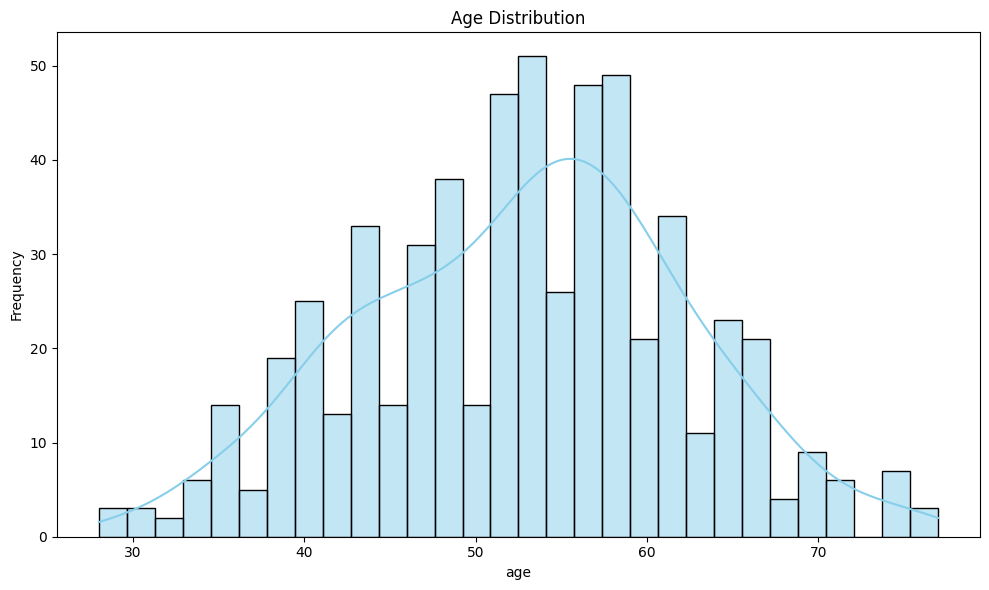

In [15]:
# Visualizing the age distribution
plt.figure(figsize=(10, 6))
plt.grid(visible=False)
sns.histplot(data=df['age'], kde=True, color='skyblue', bins=30)
plt.title('Age Distribution')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

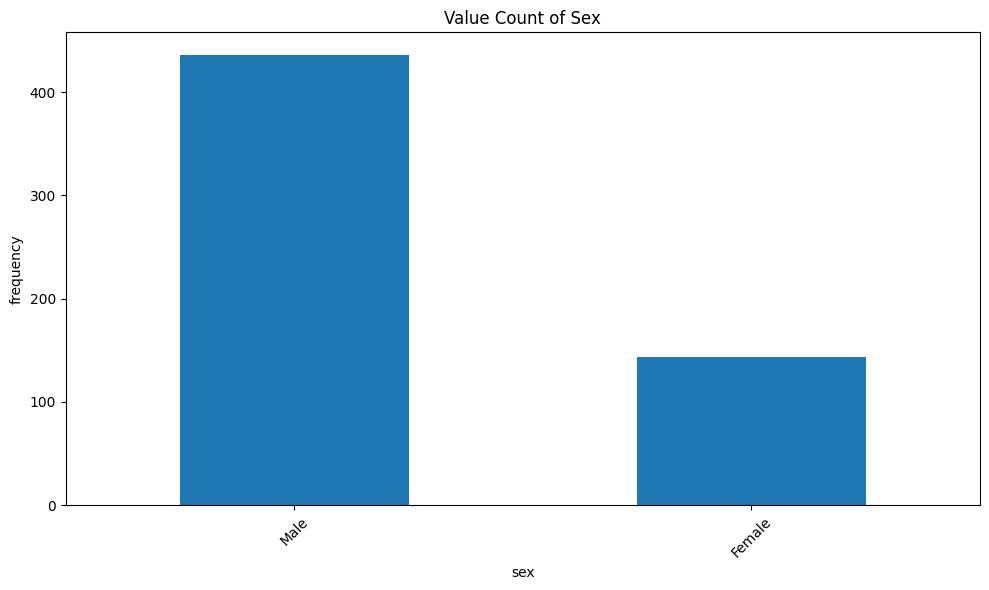

In [16]:
# Visualizing the value counts of 'sex' column
count = df['sex'].value_counts()
plt.figure(figsize=(10,6))
count.plot(kind='bar')
plt.title("Value Count of Sex")
plt.ylabel('frequency')
plt.xticks(rotation=45);
plt.tight_layout()
plt.show()

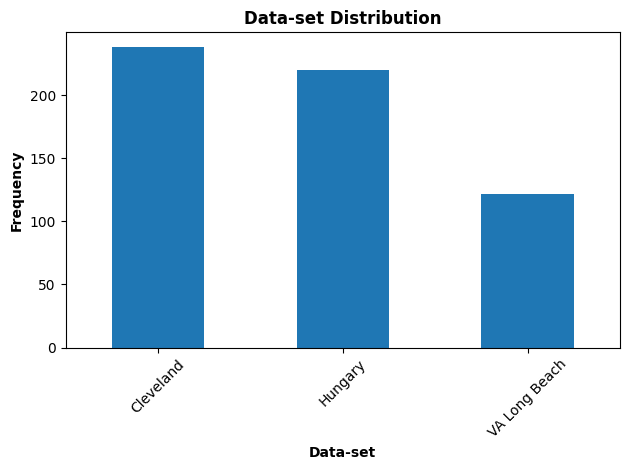

In [17]:
# Visualizing the distribution of dataset feature
dataset_count = df['dataset'].value_counts().sort_values(ascending=False)
# plotting the distribution
plt.Figure(figsize=(10, 6))
plt.grid(visible=True)
dataset_count.plot(kind='bar')
plt.title('Data-set Distribution', fontweight = 'bold')
plt.ylabel('Frequency', fontweight='bold')
plt.xlabel('Data-set', fontweight= 'bold')
plt.xticks(rotation = 45);
plt.tight_layout()
plt.show()

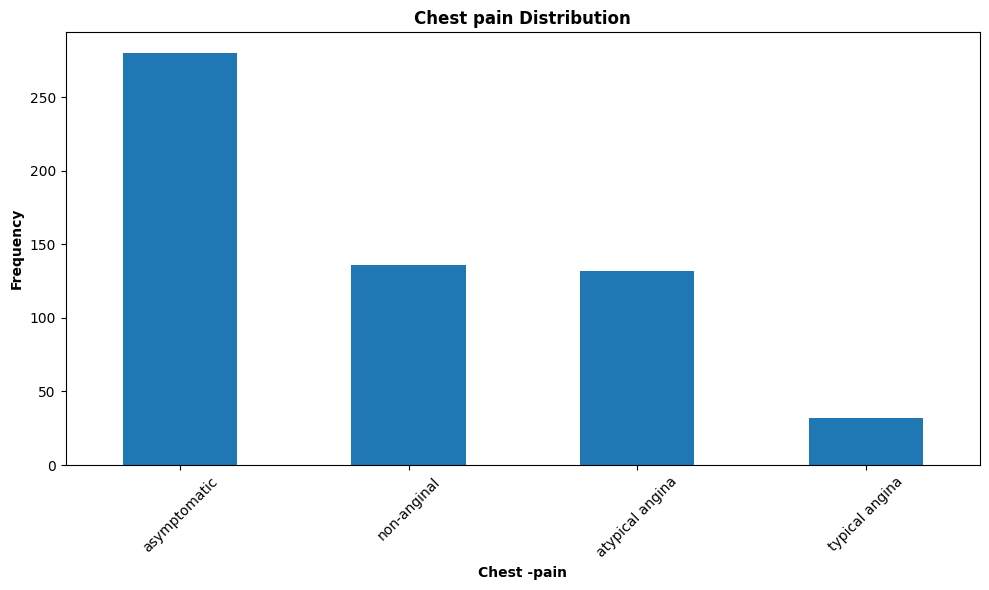

In [18]:
# Visualizing the distribution of cp feature
cp_count = df['cp'].value_counts().sort_values(ascending=False)
# plotting the distribution
plt.figure(figsize=(10, 6))
cp_count.plot(kind='bar')
plt.title('Chest pain Distribution', fontweight = 'bold')
plt.ylabel('Frequency', fontweight='bold')
plt.xlabel('Chest -pain', fontweight= 'bold')
plt.xticks(rotation = 45);
plt.tight_layout()
plt.show()

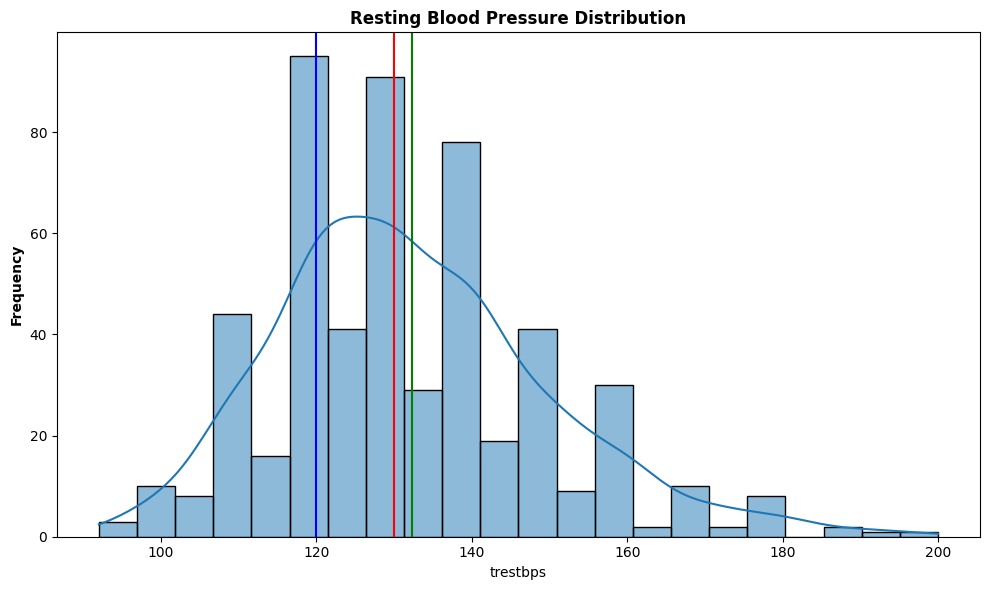

In [19]:
# Visualizing the distribution of trestbps feature
plt.figure(figsize=(10, 6))
plt.grid(visible=False)
sns.histplot(df['trestbps'], kde=True)
plt.axvline((df['trestbps'].mean()), color='green')
plt.axvline((df['trestbps'].median()), color='red')
plt.axvline((df['trestbps'].mode()[0]), color='blue')
plt.title('Resting Blood Pressure Distribution', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.tight_layout()
plt.show()

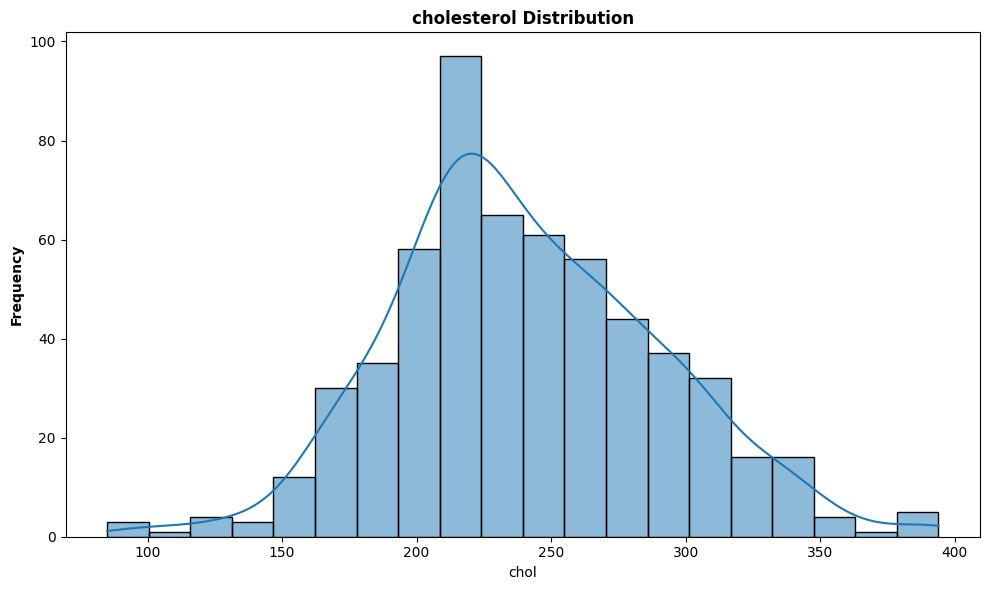

In [20]:
# Visualizing the distribution of chol feature
plt.figure(figsize=(10, 6))
plt.grid(visible=False)
sns.histplot(data=df['chol'], kde=True)
plt.title('cholesterol Distribution', fontweight = 'bold')
plt.ylabel('Frequency', fontweight='bold')
plt.tight_layout()
plt.show()

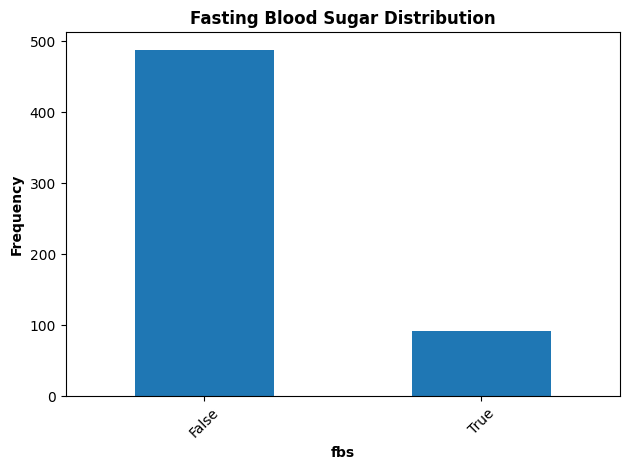

In [21]:
fbs_count = df['fbs'].value_counts().sort_values(ascending=False)

plt.Figure(figsize=(10, 6))
fbs_count.plot(kind='bar')
plt.title('Fasting Blood Sugar Distribution', fontweight = 'bold')
plt.ylabel('Frequency', fontweight='bold')
plt.xlabel('fbs', fontweight= 'bold')
plt.xticks(rotation = 45);
plt.tight_layout()
plt.show()

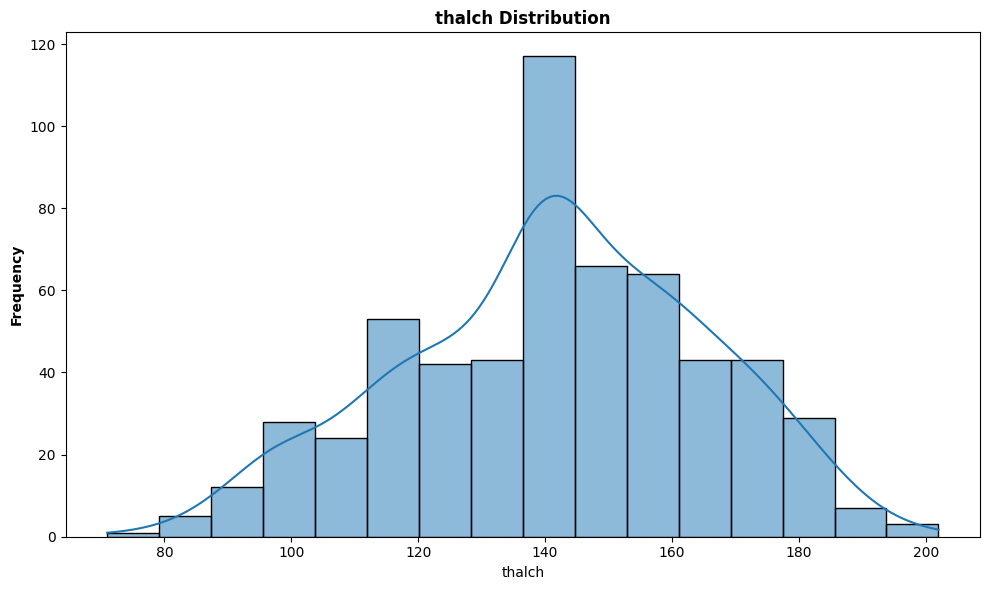

In [22]:
plt.figure(figsize=(10, 6))
plt.grid(visible=False)
sns.histplot(data=df['thalch'], kde=True)
plt.title('thalch Distribution', fontweight = 'bold')
plt.ylabel('Frequency', fontweight='bold')
plt.tight_layout()
plt.show()

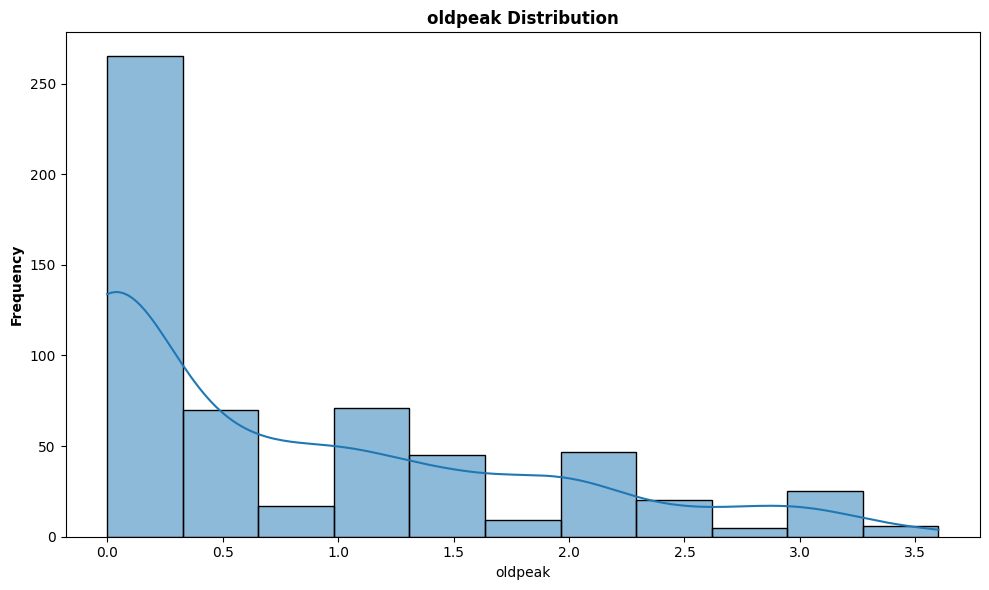

In [23]:
plt.figure(figsize=(10, 6))
plt.grid(visible=False)
sns.histplot(data=df['oldpeak'], kde=True)
plt.title('oldpeak Distribution', fontweight = 'bold')
plt.ylabel('Frequency', fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# percentage of missing values in each column
(df.isnull().sum()*100 /len(df)).sort_values(ascending=False).round(2)

,0
trestbps,6.9
sex,0.0
age,0.0
dataset,0.0
cp,0.0
chol,0.0
fbs,0.0
restecg,0.0
thalch,0.0
exang,0.0


In [25]:
df['target'].value_counts()

,count
target,
0,308
1,272


### ML Models

In [26]:
# Features with multiple categories (Nominal)
categorical_cols = ['dataset', 'cp', 'restecg', 'slope', 'thal', 'target']

# Features with only two possible values (Binary/Boolean)
bool_cols = ['sex', 'fbs', 'exang']

# Features with continuous or discrete numerical values
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

In [38]:
# Dictionary to store encoders
encoders = {}

# Corrected categorical_cols by removing 'num' which does not exist
categorical_cols = ['dataset', 'cp', 'restecg', 'slope', 'thal']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

for col in bool_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [39]:
Standard_scalers = {}

for col in numeric_cols:
    scaler = StandardScaler()
    df[col] = scaler.fit_transform(df[[col]])
    Standard_scalers[col] = scaler

In [40]:
df.head().transpose()

,2,3,5,6,9
age,0.031219,0.878596,-1.345768,-0.180625,1.514128
sex,1.000000,1.000000,1.000000,1.000000,1.000000
dataset,2.000000,0.000000,1.000000,2.000000,0.000000
cp,0.000000,0.000000,2.000000,0.000000,0.000000
trestbps,-0.474047,0.477595,0.477595,-0.117181,-0.711958
chol,0.056021,-0.712133,-0.541432,-0.285381,-0.242706
fbs,0.000000,0.000000,0.000000,1.000000,0.000000
restecg,1.000000,0.000000,1.000000,2.000000,0.000000
thalch,-0.822359,-0.154513,1.932507,-0.071032,-0.530176
exang,1.000000,1.000000,0.000000,0.000000,1.000000


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 570 entries, 2 to 735
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       570 non-null    float64
 1   sex       570 non-null    int64  
 2   dataset   570 non-null    int64  
 3   cp        570 non-null    int64  
 4   trestbps  570 non-null    float64
 5   chol      570 non-null    float64
 6   fbs       570 non-null    int64  
 7   restecg   570 non-null    int64  
 8   thalch    570 non-null    float64
 9   exang     570 non-null    int64  
 10  oldpeak   570 non-null    float64
 11  slope     570 non-null    int64  
 12  ca        570 non-null    float64
 13  thal      570 non-null    int64  
 14  target    570 non-null    int64  
dtypes: float64(6), int64(9)
memory usage: 71.2 KB


In [42]:
X = df.drop(['target','dataset'] , axis=1)
y = df['target']

In [43]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

### Model Implementation

In [45]:
np.random.seed(42)
random.seed(42)

# define stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# list of models to evaluate
models = [
    (LogisticRegression(random_state=42),
        {
            "C": [0.1, 1, 10],
            "solver": ["lbfgs", "liblinear"]
        }
    ),
    (DecisionTreeClassifier(random_state=42),
        {
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5]
        }
    ),
    (RandomForestClassifier(random_state=42),
        {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5]
        }
    ),
    (KNeighborsClassifier(),
        {
            "n_neighbors": [3, 5, 7, 9],
            "weights": ["uniform", "distance"]
        }
    ),
    (SVC(random_state=42),
        {
            "C": [0.1, 1, 10],
            "kernel": ["rbf", "linear"],
            "gamma": ["scale", "auto"]
        }
    ),
    (GradientBoostingClassifier(random_state=42),
        {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }
    )
]

results = []
best_model = None
best_accuracy = 0.0

for model, params in models:
    scores = cross_val_score(model, X_train, y_train, cv=cv)
    mean_accuracy = scores.mean()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)


    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": model.__class__.__name__,
        "CV_Accuracy": mean_accuracy,
        "Test_Accuracy": accuracy,
         "F1_Score": f1,
        "Model_Object": model
    })

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = (model.__class__.__name__, model)

# Sort results by Test_Accuracy in descending order
results_sorted = sorted(results, key=lambda x: x["Test_Accuracy"], reverse=True)

for res in results_sorted:
    print(f"Model: {res['Model']}")
    print(f"Cross-validation Accuracy: {res['CV_Accuracy']:.4f}")
    print(f"Test Accuracy: {res['Test_Accuracy']:.4f}\n")
    print(f"F1 Score: {res['F1_Score']:.4f}\n")

print("Best Model Name:", best_model[0])

NameError: name 'f1_score' is not defined

In [47]:
# F1-Score

from sklearn.metrics import accuracy_score, f1_score

results = []
best_model = None
best_accuracy = 0.0

for model, params in models:
    # Cross-validation accuracy
    scores = cross_val_score(model, X_train, y_train, cv=cv)
    mean_accuracy = scores.mean()

    # F1-Score
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": model.__class__.__name__,
        "CV_Accuracy": mean_accuracy,
        "Test_Accuracy": accuracy,
        "F1_Score": f1,
        "Model_Object": model
    })

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = (model.__class__.__name__, model)

# Sort results by Test_Accuracy in descending order
results_sorted = sorted(results, key=lambda x: x["Test_Accuracy"], reverse=True)

for res in results_sorted:
    print(f"Model: {res['Model']}")
    print(f"Cross-validation Accuracy: {res['CV_Accuracy']:.4f}")
    print(f"Test Accuracy: {res['Test_Accuracy']:.4f}")
    print(f"F1 Score: {res['F1_Score']:.4f}\n")

print("Best Model Name:", best_model[0])


Model: LogisticRegression
Cross-validation Accuracy: 0.7808
Test Accuracy: 0.8333
F1 Score: 0.8224

Model: RandomForestClassifier
Cross-validation Accuracy: 0.8027
Test Accuracy: 0.8158
F1 Score: 0.8073

Model: SVC
Cross-validation Accuracy: 0.7918
Test Accuracy: 0.8158
F1 Score: 0.8073

Model: GradientBoostingClassifier
Cross-validation Accuracy: 0.7699
Test Accuracy: 0.7895
F1 Score: 0.7778

Model: DecisionTreeClassifier
Cross-validation Accuracy: 0.7323
Test Accuracy: 0.7807
F1 Score: 0.7748

Model: KNeighborsClassifier
Cross-validation Accuracy: 0.7742
Test Accuracy: 0.7544
F1 Score: 0.7407

Best Model Name: LogisticRegression
